In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data_banknote_authentication.txt', header=None)
df.columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']

print("First Five Samples")
print(df.head())

print("\nDataset Dimensions (Rows, Columns)")
print(df.shape)

print("\nMissing Values Per Column")
print(df.isnull().sum())

print("\nDescriptive Statistics")
print(df.describe())

First Five Samples
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Dimensions (Rows, Columns)
(1372, 5)

Missing Values Per Column
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive Statistics
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.8214

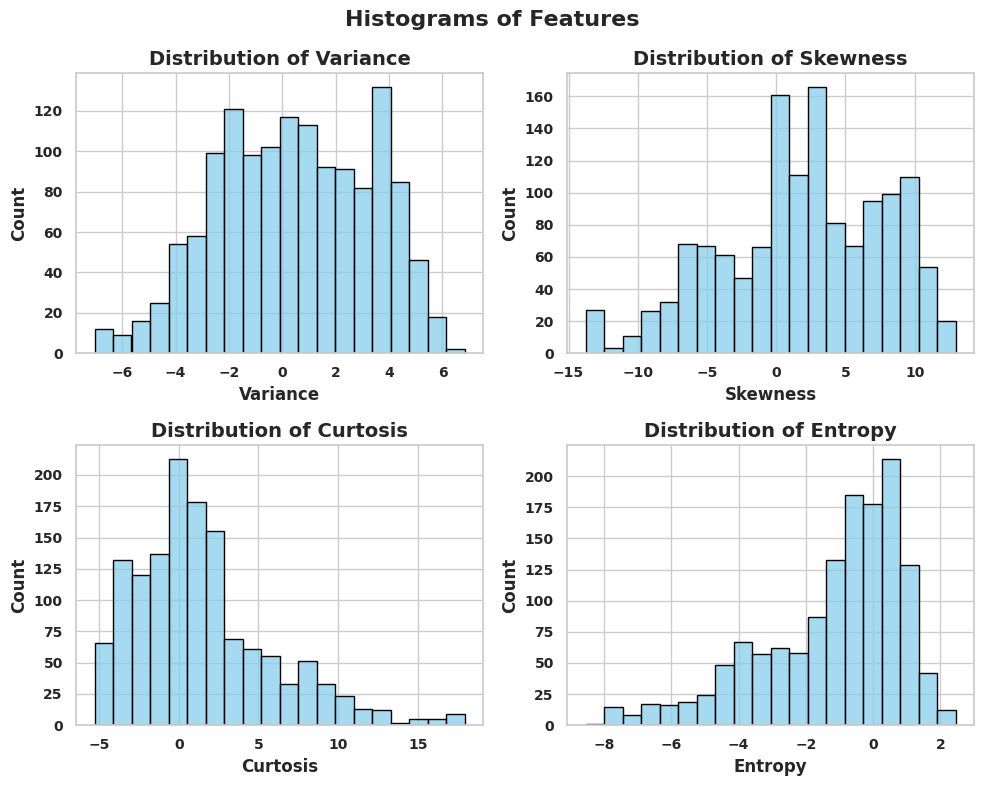

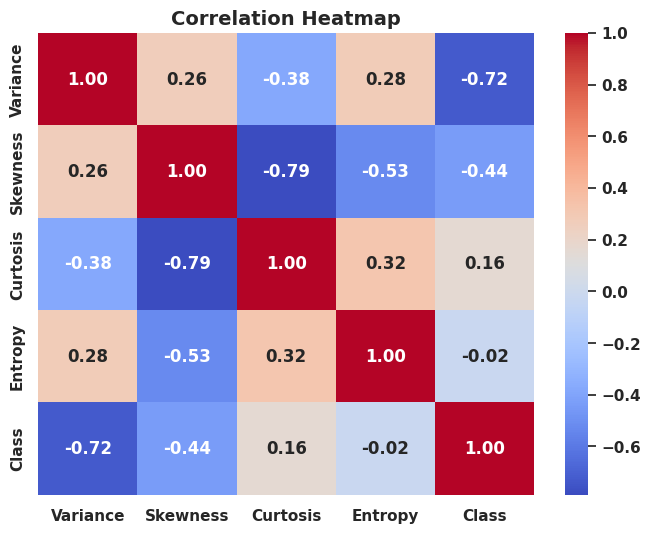

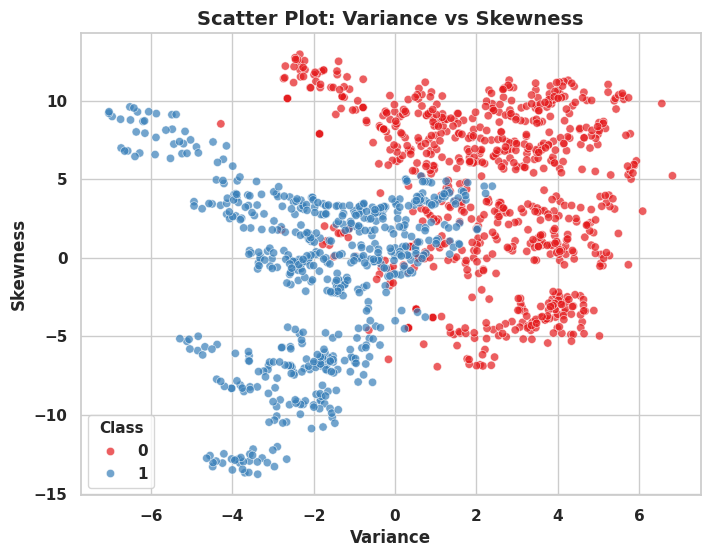

/tmp/ipykernel_499/3069281184.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(ax_box.get_xticklabels(), weight='bold', size=11)


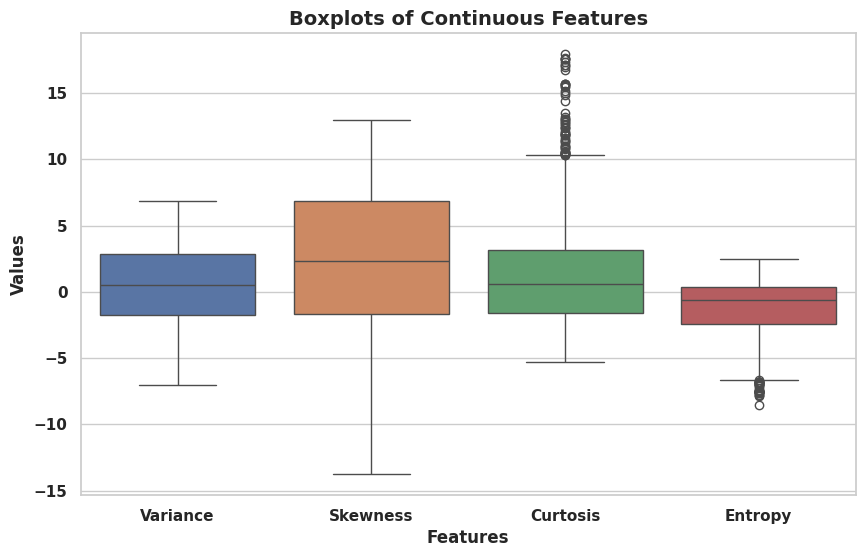

In [ ]:
sns.set_theme(style="whitegrid")

bold_font = {'weight': 'bold', 'size': 12}
title_font = {'weight': 'bold', 'size': 14}


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns[:4]):
    sns.histplot(data=df, x=col, bins=20, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontdict=title_font)
    axes[i].set_xlabel(col, fontdict=bold_font)
    axes[i].set_ylabel('Count', fontdict=bold_font)


    axes[i].tick_params(axis='both', labelsize=10)
    for label in (axes[i].get_xticklabels() + axes[i].get_yticklabels()):
        label.set_weight('bold')

plt.suptitle('Histograms of Features', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
ax_heatmap = sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
                         annot_kws={'weight': 'bold'})

plt.title('Correlation Heatmap', fontdict=title_font)
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), weight='bold', size=11)
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), weight='bold', size=11)
plt.show()

plt.figure(figsize=(8, 6))
ax_scatter = sns.scatterplot(data=df, x='Variance', y='Skewness', hue='Class', palette='Set1', alpha=0.7)

plt.title('Scatter Plot: Variance vs Skewness', fontdict=title_font)
ax_scatter.set_xlabel('Variance', fontdict=bold_font)
ax_scatter.set_ylabel('Skewness', fontdict=bold_font)

for label in (ax_scatter.get_xticklabels() + ax_scatter.get_yticklabels()):
    label.set_weight('bold')

legend = ax_scatter.get_legend()
if legend:
    legend.get_title().set_weight('bold')
    legend.get_title().set_fontsize(11)
    for text in legend.get_texts():
        text.set_weight('bold')

plt.show()
plt.figure(figsize=(10, 6))
ax_box = sns.boxplot(data=df.iloc[:, :4])

plt.title('Boxplots of Continuous Features', fontdict=title_font)
ax_box.set_xlabel('Features', fontdict=bold_font)
ax_box.set_ylabel('Values', fontdict=bold_font)

ax_box.set_xticklabels(ax_box.get_xticklabels(), weight='bold', size=11)
for label in ax_box.get_yticklabels():
    label.set_weight('bold')

plt.show()

In [ ]:
X = df.iloc[:, :4].values
y = df.iloc[:, 4].values

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Set Dimensions: Features {X_train.shape}, Labels {y_train.shape}")
print(f"Testing Set Dimensions: Features {X_test.shape}, Labels {y_test.shape}")

Training Set Dimensions: Features (1097, 4), Labels (1097,)
Testing Set Dimensions: Features (275, 4), Labels (275,)


In [ ]:
import numpy as np

class PerceptronScratch:
    def __init__(self, learning_rate=0.01, epochs=15):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

        # Lists to store metrics for plotting
        self.history_errors = []
        self.history_weights = []
        self.history_bias = []

    def _step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit_with_logs(self, X, y):
        n_samples, n_features = X.shape

        np.random.seed(42)
        self.weights = np.random.uniform(-0.01, 0.01, n_features)
        self.bias = np.random.uniform(-0.01, 0.01)

        self.history_errors = []
        self.history_weights = []
        self.history_bias = []

        print("=" * 85)
        print(f"{'Epoch':<7} | {'Misclassified':<14} | {'Updated Bias':<13} | {'Updated Weights':<30}")
        print("=" * 85)

        for epoch in range(1, self.epochs + 1):
            misclassified = 0

            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self._step_activation(linear_output)

                update = self.lr * (y[idx] - y_predicted)
                if update != 0.0:
                    self.weights += update * x_i
                    self.bias += update
                    misclassified += 1

            self.history_errors.append(misclassified)
            self.history_weights.append(self.weights.copy())
            self.history_bias.append(self.bias)

            weights_str = str(np.round(self.weights, 4).tolist())
            print(f"{epoch:<7} | {misclassified:<14} | {round(self.bias, 4):<13} | {weights_str:<30}")

        print("=" * 85)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._step_activation(linear_output)

In [ ]:
perceptron = PerceptronScratch(0.01, 50)
perceptron.fit_with_logs(X_train, y_train)

Epoch   | Misclassified  | Updated Bias  | Updated Weights               
1       | 52             | -0.0269       | [-0.0601, -0.0756, -0.0639, 0.0034]
2       | 23             | -0.0369       | [-0.0766, -0.0973, -0.0598, 0.0123]
3       | 24             | -0.0369       | [-0.0878, -0.0966, -0.0812, -0.0059]
4       | 26             | -0.0369       | [-0.0872, -0.1126, -0.0955, 0.0013]
5       | 19             | -0.0469       | [-0.0987, -0.1181, -0.0988, -0.0053]
6       | 25             | -0.0569       | [-0.0969, -0.1299, -0.1107, -0.0086]
7       | 23             | -0.0669       | [-0.1032, -0.1289, -0.1176, 0.0085]
8       | 22             | -0.0469       | [-0.1172, -0.1437, -0.1179, 0.0023]
9       | 20             | -0.0669       | [-0.1076, -0.1444, -0.1312, -0.0062]
10      | 25             | -0.0569       | [-0.1353, -0.1515, -0.1213, -0.0095]
11      | 23             | -0.0669       | [-0.1182, -0.1576, -0.1412, -0.0075]
12      | 16             | -0.0669       | [-0.1241

--- Evaluation Metrics From Scratch ---
Accuracy:  0.9855
Precision: 0.9683
Recall:    1.0000
F1-Score:  0.9839

Confusion Matrix:
[[149   4]
 [  0 122]]


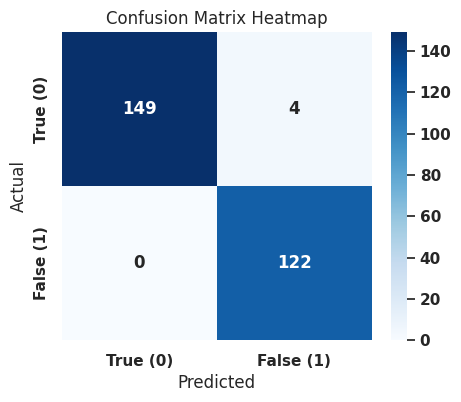

In [ ]:
y_pred = perceptron.predict(X_test)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    confusion_matrix = np.array([[tn, fp], [fn, tp]])

    return accuracy, precision, recall, f1_score, confusion_matrix

accuracy, precision, recall, f1, cm = compute_metrics(y_test, y_pred)

print("--- Evaluation Metrics From Scratch ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['True (0)', 'False (1)'],
            yticklabels=['True (0)', 'False (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Heatmap')
plt.show()

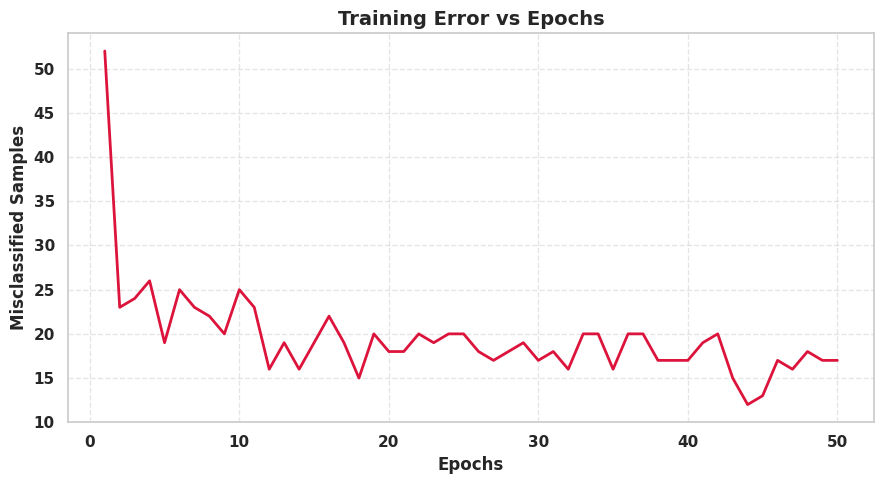

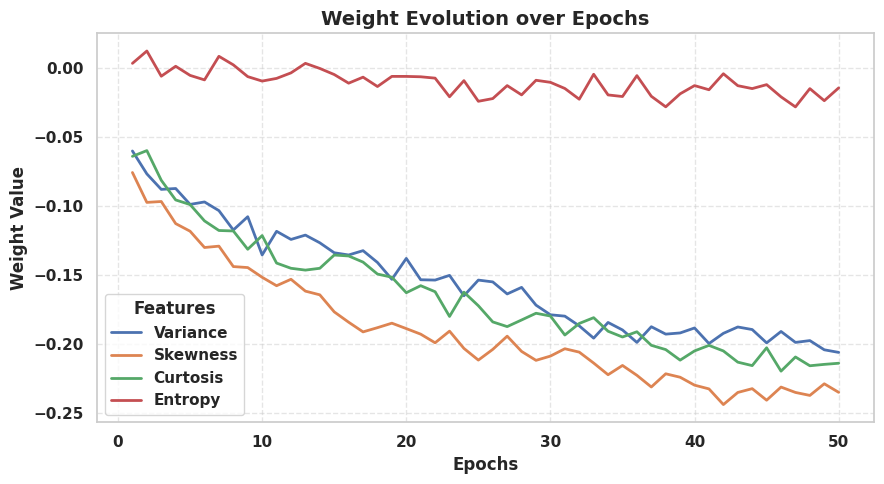

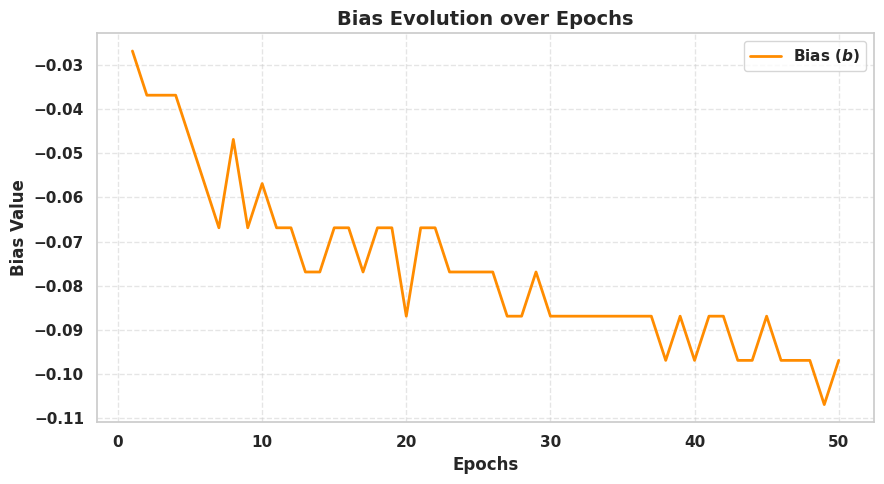

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Styling settings for bold weights
bold_font = {'weight': 'bold', 'size': 12}
title_font = {'weight': 'bold', 'size': 14}
epochs_range = range(1, len(perceptron.history_errors) + 1)

# Set global configuration for axis numbers to be bold
plt.rc('font', weight='bold')

# 1. Training Error vs Epochs
plt.figure(figsize=(9, 5))
# Removed marker='o' for a cleaner continuous line over large epochs
plt.plot(epochs_range, perceptron.history_errors, color='crimson', linewidth=2)
plt.title('Training Error vs Epochs', fontdict=title_font)
plt.xlabel('Epochs', fontdict=bold_font)
plt.ylabel('Misclassified Samples', fontdict=bold_font)

# Removed explicit plt.xticks() to let matplotlib dynamically auto-scale ticks
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Weight Evolution
plt.figure(figsize=(9, 5))
weights_matrix = np.array(perceptron.history_weights)
feature_names = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

# Plotting lines without markers for scalability
for i in range(weights_matrix.shape[1]):
    plt.plot(epochs_range, weights_matrix[:, i], label=feature_names[i], linewidth=2)

plt.title('Weight Evolution over Epochs', fontdict=title_font)
plt.xlabel('Epochs', fontdict=bold_font)
plt.ylabel('Weight Value', fontdict=bold_font)

plt.grid(True, linestyle='--', alpha=0.5)

# Make legend title and items bold
legend_w = plt.legend(title='Features', loc='best')
legend_w.get_title().set_weight('bold')
for text in legend_w.get_texts():
    text.set_weight('bold')
plt.tight_layout()
plt.show()

# 3. Bias Evolution
plt.figure(figsize=(9, 5))
# Removed marker='^' for scalable rendering
plt.plot(epochs_range, perceptron.history_bias, color='darkorange', linewidth=2, label='Bias ($b$)')
plt.title('Bias Evolution over Epochs', fontdict=title_font)
plt.xlabel('Epochs', fontdict=bold_font)
plt.ylabel('Bias Value', fontdict=bold_font)

plt.grid(True, linestyle='--', alpha=0.5)

# Make legend items bold
legend_b = plt.legend(loc='best')
for text in legend_b.get_texts():
    text.set_weight('bold')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Gather all configuration and metrics details
summary_data = {
    "Metric / Parameter": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value / Details": [
        f"{df.shape[0]} samples ({df.shape[1]} columns)",
        f"Training: {X_train.shape[0]} samples (80%) | Testing: {X_test.shape[0]} samples (20%)",
        f"{perceptron.lr}",
        f"{len(perceptron.history_errors)} (Max limit was {perceptron.epochs})",
        f"{np.round(perceptron.weights, 4)}",
        f"{round(perceptron.bias, 4)}",
        f"{accuracy:.4%}",
        f"{precision:.4%}",
        f"{recall:.4%}",
        f"{f1:.4%}"
    ]
}

# 2. Convert into a Pandas DataFrame for presentation
summary_table = pd.DataFrame(summary_data)

# 3. Print the table with enhanced visual framing
print("="*65)
print("              PERCEPTRON MODEL SUMMARY REPORT")
print("="*65)
print(summary_table.to_string(index=False))
print("="*65)

              PERCEPTRON MODEL SUMMARY REPORT
Metric / Parameter                                           Value / Details
      Dataset Size                                  1372 samples (5 columns)
  Train/Test Split Training: 1097 samples (80%) | Testing: 275 samples (20%)
     Learning Rate                                                      0.01
            Epochs                                     50 (Max limit was 50)
     Final Weights                         [-0.2058 -0.2347 -0.2137 -0.0144]
        Final Bias                                                   -0.0969
          Accuracy                                                  98.5455%
         Precision                                                  96.8254%
            Recall                                                 100.0000%
          F1-score                                                  98.3871%



Training Tracking Session for Learning Rate: 0.1
Epoch   | Misclassified  | Updated Bias  | Updated Weights               
1       | 55             | -0.3069       | [-0.568, -0.8848, -0.6897, 0.0151]
2       | 17             | -0.4069       | [-0.6018, -0.8832, -0.7729, -0.0062]
3       | 28             | -0.4069       | [-0.808, -0.9312, -0.9267, -0.0168]
4       | 26             | -0.4069       | [-0.9415, -1.1854, -0.8105, -0.0048]
5       | 21             | -0.5069       | [-0.8248, -1.1825, -1.0639, -0.0139]
6       | 21             | -0.4069       | [-1.0676, -1.2853, -0.9987, -0.0411]
7       | 23             | -0.5069       | [-1.1973, -1.3107, -0.9977, 0.0426]
8       | 26             | -0.5069       | [-1.1226, -1.4739, -1.1001, -0.0658]
9       | 18             | -0.5069       | [-1.2343, -1.4539, -1.1059, -0.0769]
10      | 22             | -0.5069       | [-1.2945, -1.5185, -1.2171, -0.1165]
11      | 22             | -0.5069       | [-1.2822, -1.6442, -1.2743, -0.0418]


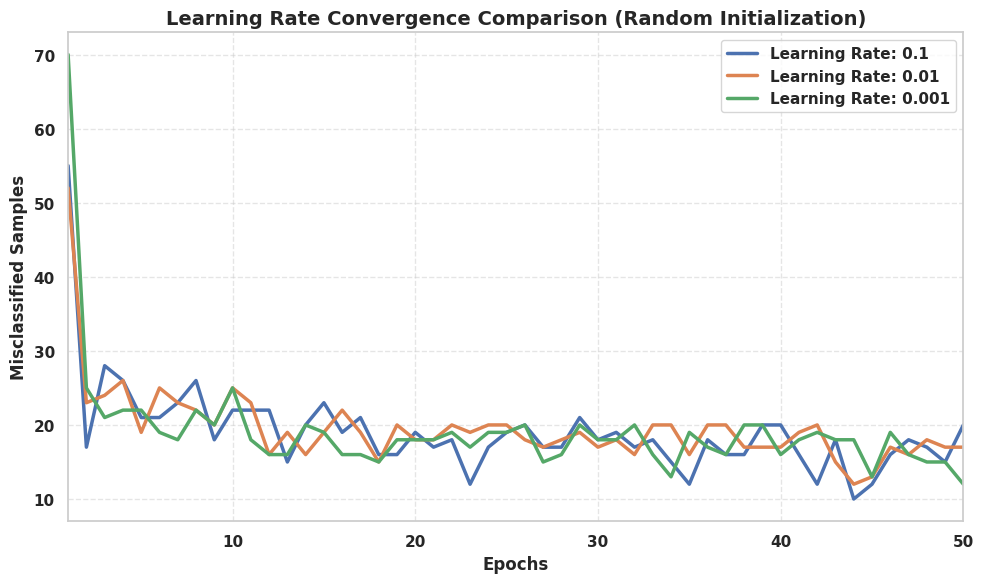

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
max_epochs = 50
lr_histories = {}

# Train and collect non-overlapping random states
for lr in learning_rates:
    print(f"\nTraining Tracking Session for Learning Rate: {lr}")
    model = PerceptronScratch(learning_rate=lr, epochs=max_epochs)
    model.fit_with_logs(X_train, y_train)
    lr_histories[lr] = model.history_errors

# Generate the Comparative Chart
bold_font = {'weight': 'bold', 'size': 12}
title_font = {'weight': 'bold', 'size': 14}

plt.figure(figsize=(10, 6))
plt.rc('font', weight='bold')

epochs_range = range(1, max_epochs + 1)

for lr in learning_rates:
    plt.plot(epochs_range, lr_histories[lr], linewidth=2.5, label=f"Learning Rate: {lr}")

plt.title('Learning Rate Convergence Comparison (Random Initialization)', fontdict=title_font)
plt.xlabel('Epochs', fontdict=bold_font)
plt.ylabel('Misclassified Samples', fontdict=bold_font)
plt.xlim(1, max_epochs)
plt.grid(True, linestyle='--', alpha=0.5)

legend = plt.legend(loc='best')
for text in legend.get_texts():
    text.set_weight('bold')

plt.tight_layout()
plt.show()


===== OR Gate =====
Update 0: weights (bias, w1, w2) = [0. 0. 0.]
Update 1: weights (bias, w1, w2) = [-0.1  0.   0. ]
Update 2: weights (bias, w1, w2) = [0.  0.  0.1]
Update 3: weights (bias, w1, w2) = [-0.1  0.   0.1]
Update 4: weights (bias, w1, w2) = [0.  0.1 0.1]
Update 5: weights (bias, w1, w2) = [-0.1  0.1  0.1]


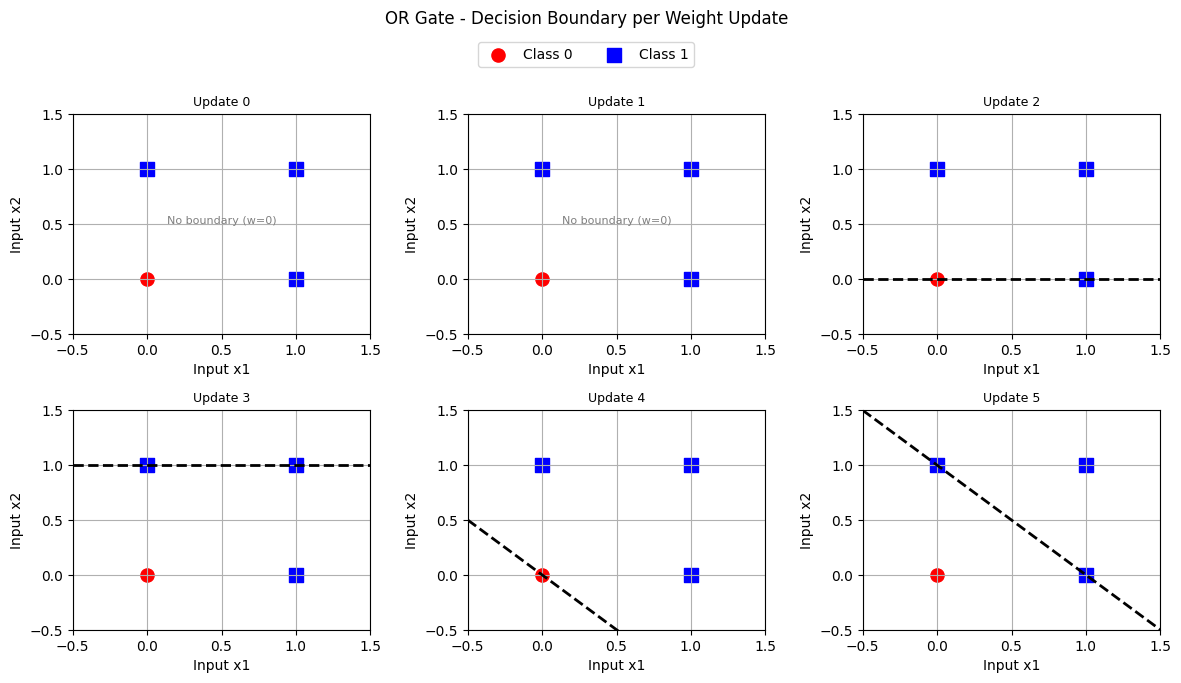

Converged final weights: [-0.1  0.1  0.1]

===== AND Gate =====
Update 0: weights (bias, w1, w2) = [0. 0. 0.]
Update 1: weights (bias, w1, w2) = [-0.1  0.   0. ]
Update 2: weights (bias, w1, w2) = [0.  0.1 0.1]
Update 3: weights (bias, w1, w2) = [-0.1  0.1  0.1]
Update 4: weights (bias, w1, w2) = [-0.2  0.1  0. ]
Update 5: weights (bias, w1, w2) = [-0.1  0.2  0.1]
Update 6: weights (bias, w1, w2) = [-0.2  0.2  0. ]
Update 7: weights (bias, w1, w2) = [-0.3  0.1  0. ]
Update 8: weights (bias, w1, w2) = [-0.2  0.2  0.1]


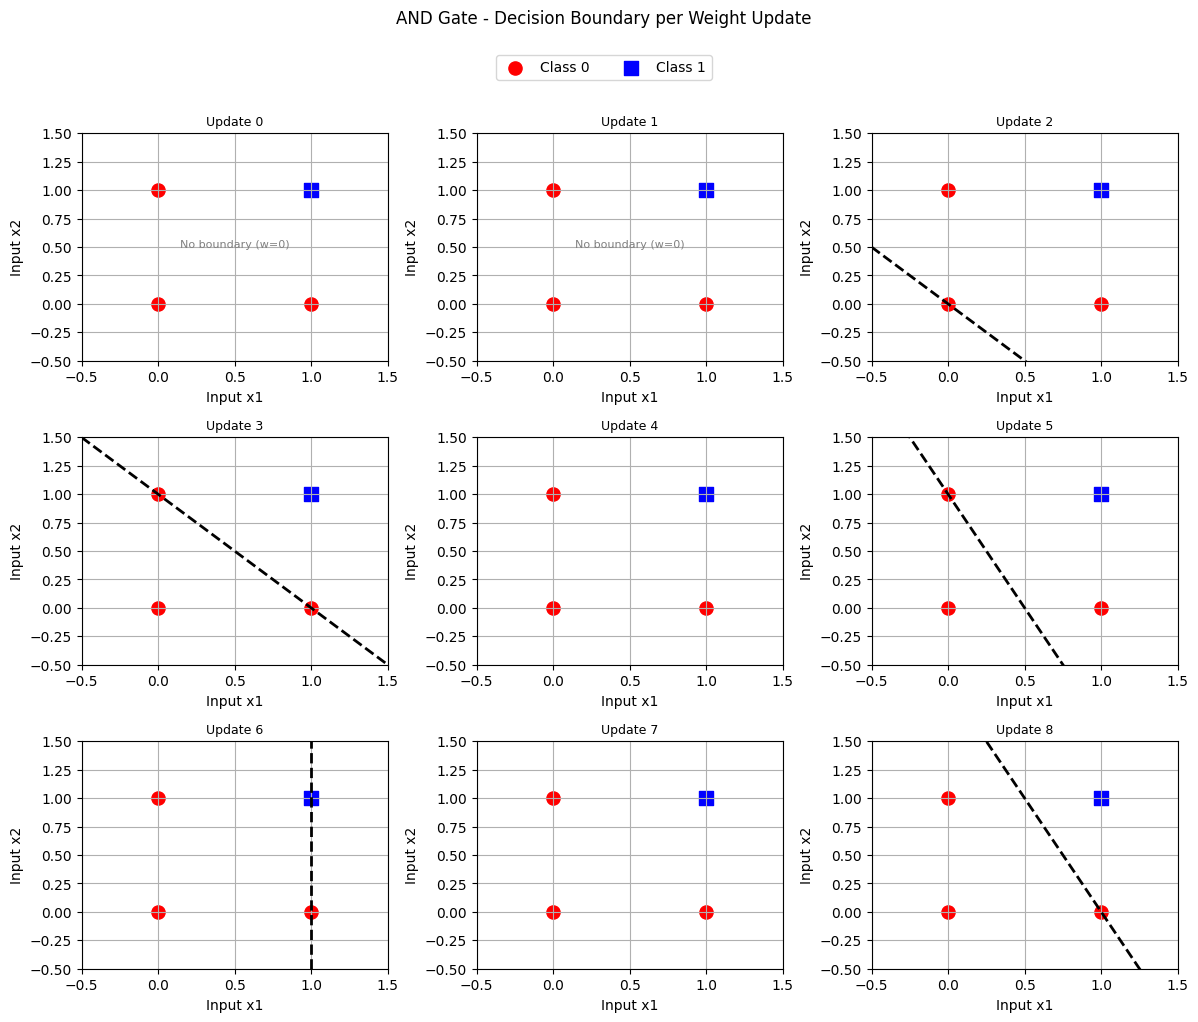

Converged final weights: [-0.2  0.2  0.1]

===== NOT Gate =====
Update 0: weights (bias, w1) = [0. 0.]
Update 1: weights (bias, w1) = [-0.1 -0.1]
Update 2: weights (bias, w1) = [ 0.  -0.1]


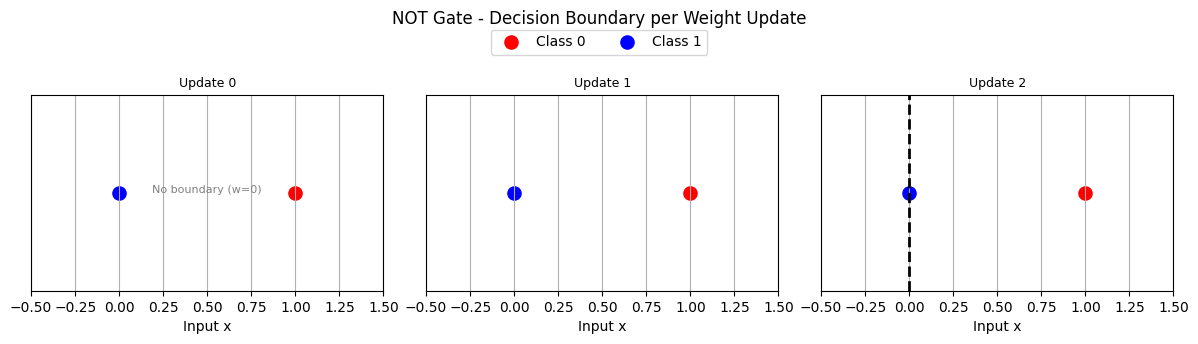

Converged final weights: [ 0.  -0.1]


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_train(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1] + 1)
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    history = [w.copy()]
    for epoch in range(epochs):
        changed = False
        for i in range(len(Xb)):
            pred = 1 if np.dot(w, Xb[i]) >= 0 else 0
            if pred != y[i]:
                w = w + lr * (y[i] - pred) * Xb[i]
                history.append(w.copy())
                changed = True
        if not changed:
            break
    return w, history

def draw_2d(ax, X, y, w, title):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', color='red', s=90, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker='s', color='blue', s=90, label='Class 1')
    xv = np.array([-0.5, 1.5])
    if w[2] != 0:
        yv = -(w[0] + w[1] * xv) / w[2]
        ax.plot(xv, yv, 'k--', linewidth=2, label='Decision boundary')
    elif w[1] != 0:
        ax.axvline(x=-w[0] / w[1], color='k', linestyle='--', linewidth=2, label='Decision boundary')
    else:
        ax.text(0.5, 0.5, 'No boundary (w=0)', ha='center', color='gray', fontsize=8)
    ax.set_xlabel('Input x1')
    ax.set_ylabel('Input x2')
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True)

def draw_1d(ax, X, y, w, title):
    ax.scatter(X[y == 0], np.zeros_like(X[y == 0]), color='red', s=90, label='Class 0')
    ax.scatter(X[y == 1], np.zeros_like(X[y == 1]), color='blue', s=90, label='Class 1')
    if w[1] != 0:
        ax.axvline(x=-w[0] / w[1], color='k', linestyle='--', linewidth=2, label='Decision boundary')
    else:
        ax.text(0.5, 0, 'No boundary (w=0)', ha='center', color='gray', fontsize=8)
    ax.set_xlabel('Input x')
    ax.set_yticks([])
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.grid(True)

gates = {
    'OR':  (np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), np.array([0, 1, 1, 1])),
    'AND': (np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), np.array([0, 0, 0, 1])),
    'NOT': (np.array([[0], [1]]), np.array([1, 0])),
}

for name, (X, y) in gates.items():
    print(f"\n===== {name} Gate =====")
    w_final, history = perceptron_train(X, y)

    n = len(history)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(-1)

    for i, w in enumerate(history):
        if X.shape[1] == 2:
            draw_2d(axes[i], X, y, w, f"Update {i}")
        else:
            draw_1d(axes[i], X, y, w, f"Update {i}")
        print(f"Update {i}: weights (bias, w1{', w2' if X.shape[1] == 2 else ''}) = {w}")

    for j in range(n, len(axes)):
        axes[j].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{name} Gate - Decision Boundary per Weight Update", y=1.06, fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Converged final weights: {w_final}")

===== XOR Gate (single perceptron) =====
Update 0: weights (bias, w1, w2) = [0. 0. 0.]
Update 39: weights (bias, w1, w2) = [-0.1 -0.1  0. ]
Update 78: weights (bias, w1, w2) = [ 0.  -0.1  0. ]


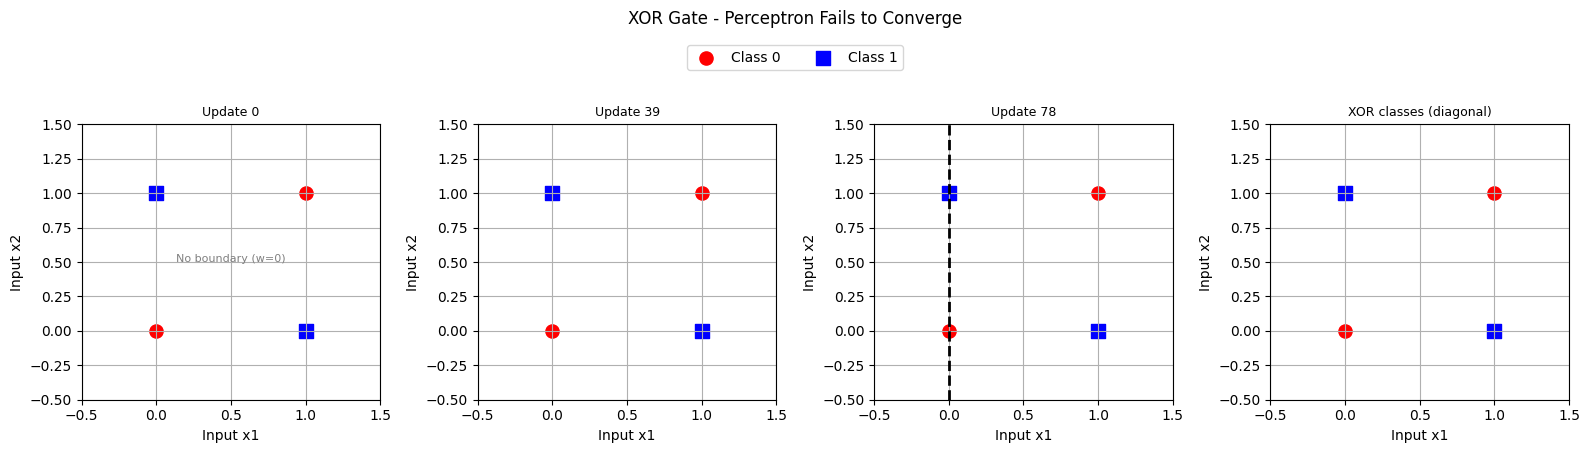


Full weight-update history:
Update 0: weights (bias, w1, w2) = [0. 0. 0.]
Update 1: weights (bias, w1, w2) = [-0.1  0.   0. ]
Update 2: weights (bias, w1, w2) = [0.  0.  0.1]
Update 3: weights (bias, w1, w2) = [-0.1 -0.1  0. ]
Update 4: weights (bias, w1, w2) = [ 0.  -0.1  0.1]
Update 5: weights (bias, w1, w2) = [0.1 0.  0.1]
Update 6: weights (bias, w1, w2) = [ 0.  -0.1  0. ]
Update 7: weights (bias, w1, w2) = [-0.1 -0.1  0. ]
Update 8: weights (bias, w1, w2) = [ 0.  -0.1  0.1]
Update 9: weights (bias, w1, w2) = [0.1 0.  0.1]
Update 10: weights (bias, w1, w2) = [ 0.  -0.1  0. ]
Update 11: weights (bias, w1, w2) = [-0.1 -0.1  0. ]
Update 12: weights (bias, w1, w2) = [ 0.  -0.1  0.1]
Update 13: weights (bias, w1, w2) = [0.1 0.  0.1]
Update 14: weights (bias, w1, w2) = [ 0.  -0.1  0. ]
Update 15: weights (bias, w1, w2) = [-0.1 -0.1  0. ]
Update 16: weights (bias, w1, w2) = [ 0.  -0.1  0.1]
Update 17: weights (bias, w1, w2) = [0.1 0.  0.1]
Update 18: weights (bias, w1, w2) = [ 0.  -0.1  

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_train(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1] + 1)
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    history = [w.copy()]
    converged = False
    for epoch in range(epochs):
        changed = False
        for i in range(len(Xb)):
            pred = 1 if np.dot(w, Xb[i]) >= 0 else 0
            if pred != y[i]:
                w = w + lr * (y[i] - pred) * Xb[i]
                history.append(w.copy())
                changed = True
        if not changed:
            converged = True
            break
    return w, history, converged

def draw_boundary(ax, X, y, w, title):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', color='red', s=90, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker='s', color='blue', s=90, label='Class 1')
    xv = np.array([-0.5, 1.5])
    if w[2] != 0:
        yv = -(w[0] + w[1] * xv) / w[2]
        ax.plot(xv, yv, 'k--', linewidth=2, label='Decision boundary')
    elif w[1] != 0:
        ax.axvline(x=-w[0] / w[1], color='k', linestyle='--', linewidth=2, label='Decision boundary')
    else:
        ax.text(0.5, 0.5, 'No boundary (w=0)', ha='center', color='gray', fontsize=8)
    ax.set_xlabel('Input x1')
    ax.set_ylabel('Input x2')
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])   # XOR

print("===== XOR Gate (single perceptron) =====")
w_final, history, converged = perceptron_train(X, y, lr=0.1, epochs=20)

sample_idxs = sorted(set([0, len(history)//2, len(history)-1]))

fig, axes = plt.subplots(1, len(sample_idxs) + 1, figsize=(4 * (len(sample_idxs) + 1), 4))

for ax, i in zip(axes, sample_idxs):
    draw_boundary(ax, X, y, history[i], f"Update {i}")
    print(f"Update {i}: weights (bias, w1, w2) = {history[i]}")

axes[-1].scatter(X[y == 0, 0], X[y == 0, 1], marker='o', color='red', s=90, label='Class 0')
axes[-1].scatter(X[y == 1, 0], X[y == 1, 1], marker='s', color='blue', s=90, label='Class 1')
axes[-1].set_xlabel('Input x1')
axes[-1].set_ylabel('Input x2')
axes[-1].set_title('XOR classes (diagonal)', fontsize=9)
axes[-1].set_xlim(-0.5, 1.5)
axes[-1].set_ylim(-0.5, 1.5)
axes[-1].grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("XOR Gate - Perceptron Fails to Converge", y=1.12, fontsize=12)
plt.tight_layout()
plt.show()

print("\nFull weight-update history:")
for i, w in enumerate(history):
    print(f"Update {i}: weights (bias, w1, w2) = {w}")
print(f"\nConverged: {converged}")
print(f"Weights after 20 epochs (not a solution): {w_final}")